# 🧠 EDA Notebook hands-on
This notebook applies Exploratory Data Analysis to a customer retail dataset.

## 📦 1. Setup & Sample Data
We create a customer dataset with missing values and outliers to simulate real-world data.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(7)

n = 200

df = pd.DataFrame({
    "age": np.random.randint(18, 70, n),
    "purchase_amount": np.random.normal(300, 80, n).round(2),
    "currency": np.random.choice(["USD"], n),
    "gender": np.random.choice(["Male", "Female"], n),
    "region": np.random.choice(["North", "South", "East", "West"], n),
    "membership_years": np.random.randint(0, 20, n)
})

# Introduce missing values
df.loc[np.random.choice(df.index, 20), "purchase_amount"] = np.nan
df.loc[np.random.choice(df.index, 15), "gender"] = np.nan

# Introduce outliers
df.loc[0, "purchase_amount"] = 2500
df.loc[1, "purchase_amount"] = 2

df.head(15)

,age,purchase_amount,currency,gender,region,membership_years
0,65,2500.00,USD,Male,South,15
1,22,2.00,USD,Male,South,17
2,43,437.42,USD,Female,East,7
3,21,263.35,USD,NaN,East,18
4,37,276.96,USD,Female,South,14
5,41,323.98,USD,Male,West,16
6,57,384.48,USD,Male,East,17
7,46,345.27,USD,Female,South,7
8,32,201.32,USD,Male,South,7
9,41,314.63,USD,Male,South,18


### Q1: Does purchase amount increase with age?

In [24]:
df.shape

(200, 6)

In [25]:
df.dtypes

age                   int32
purchase_amount     float64
currency                str
gender                  str
region                  str
membership_years      int32
dtype: object

In [26]:
df.isnull().sum()

age                  0
purchase_amount     20
currency             0
gender              15
region               0
membership_years     0
dtype: int64

In [27]:
df.describe()

,age,purchase_amount,membership_years
count,200.00000,180.000000,200.000000
mean,43.03000,302.941778,9.745000
std,14.70887,181.413702,5.442248
min,18.00000,2.000000,0.000000
25%,30.00000,247.180000,5.000000
50%,44.00000,293.400000,10.000000
75%,56.00000,347.405000,14.000000
max,69.00000,2500.000000,19.000000


In [28]:
df["purchase_amount"] = df["purchase_amount"].fillna(
    df["purchase_amount"].median()
)

df["gender"] = df["gender"].fillna(
    df["gender"].mode()[0]
)

df.head(20)

,age,purchase_amount,currency,gender,region,membership_years
0,65,2500.00,USD,Male,South,15
1,22,2.00,USD,Male,South,17
2,43,437.42,USD,Female,East,7
3,21,263.35,USD,Female,East,18
4,37,276.96,USD,Female,South,14
5,41,323.98,USD,Male,West,16
6,57,384.48,USD,Male,East,17
7,46,345.27,USD,Female,South,7
8,32,201.32,USD,Male,South,7
9,41,314.63,USD,Male,South,18


In [29]:
Q1 = df["purchase_amount"].quantile(0.25)
Q3 = df["purchase_amount"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["purchase_amount"] = np.where(df["purchase_amount"] > upper, upper, df["purchase_amount"])
df["purchase_amount"] = np.where(df["purchase_amount"] < lower, lower, df["purchase_amount"])

#Q1: Does purchase amount increase with age?

In [30]:
df[["age", "purchase_amount"]].corr()

,age,purchase_amount
age,1.000000,0.091613
purchase_amount,0.091613,1.000000


### Q2: Do loyal customers (longer membership) spend more?

In [31]:
df[["membership_years", "purchase_amount"]].corr()

,membership_years,purchase_amount
membership_years,1.000000,-0.031655
purchase_amount,-0.031655,1.000000


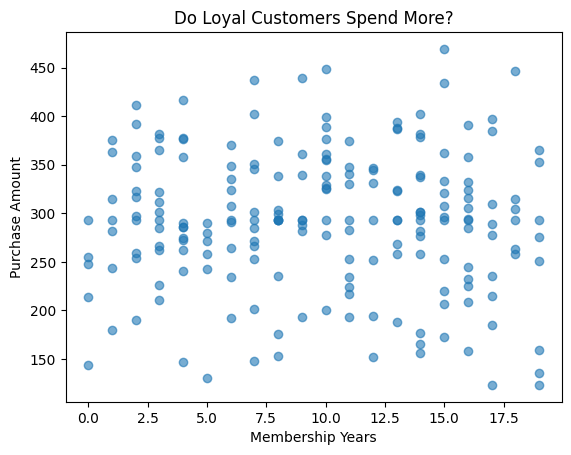

In [32]:
plt.scatter(df["membership_years"], df["purchase_amount"], alpha=0.6)
plt.xlabel("Membership Years")
plt.ylabel("Purchase Amount")
plt.title("Do Loyal Customers Spend More?")
plt.show()

### Q3: Which customer segment (gender × region) is the most valuable?

In [33]:
segment_value = df.groupby(["gender", "region"])["purchase_amount"] \
    .sum() \
    .sort_values(ascending=False)

segment_value

gender  region
Female  East      9669.75000
        South     8675.83000
        North     8046.49000
        West      7394.19875
Male    North     6802.23000
        East      6527.70000
        West      5708.34000
        South     5671.02750
Name: purchase_amount, dtype: float64

In [34]:
segment_value.head(1)

gender  region
Female  East      9669.75
Name: purchase_amount, dtype: float64

In [35]:
pivot_segment = df.pivot_table(
    values="purchase_amount",
    index="region",
    columns="gender",
    aggfunc="sum"
)

pivot_segment

gender,Female,Male
region,,
East,9669.75000,6527.7000
North,8046.49000,6802.2300
South,8675.83000,5671.0275
West,7394.19875,5708.3400


### Q4: Display the total purchased amount in EUR

In [36]:
import urllib.request
import json

# Free API — no key required: https://open.er-api.com
url = "https://open.er-api.com/v6/latest/USD"

with urllib.request.urlopen(url) as response:
    data = json.loads(response.read())

usd_to_eur = data["rates"]["EUR"]
usd_to_eur



0.851881

In [42]:
total_usd = df["purchase_amount"].sum()
# total_eur = total_usd * usd_to_eur

print(f"USD total: {total_usd:,.2f}")
# print(f"EUR total: {total_eur:,.2f}")

df["purchase_amount_eur"] = (
    df["purchase_amount"] * usd_to_eur
)

total_eur = df["purchase_amount_eur"].sum()

print(f"EUR total: {total_eur:,.2f}")

USD total: 58,495.57
EUR total: 49,831.26
